# 02 — Sentiment Analysis

Scores all Reddit posts with VADER and FinBERT, aggregates to daily weighted scores, and visualises sentiment time series around each event.

**Prerequisite:** Run notebook 01 first.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from utils import EVENT_DATES

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2a. Run sentiment scoring

FinBERT is slow on CPU — expect ~20 min. Runs once; re-run only if you delete processed files.

In [2]:
import sentiment
sentiment.run()

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: dlopen(/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <AFB7C78A-1D52-38B1-9D33-93A75FA7D528> /Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/torchvision/image.so
  Expected in:     <709C1DF5-D253-3C66-87E2-C99FD3A259DF> /Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/torch/lib/libtorch_cpu.dylib
  warn(f"Failed to load image Python extension: {e}")
2026-05-05 19:55:35,300  FinBERT not available (cannot import name 'pipeline' from 'transformers' (/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/transformers/__init__.py)) — running VADER only
2026-05-05 19:55:35,321  [teaser_trailer]  15 posts
2026-05-05 19:55:35,321  [teaser_trailer]  Running VADER...
/Users/jamilasabazova/quant-proje

## 2b. Load scores

In [3]:
scores = pd.read_csv('../data/processed/sentiment_scores.csv', parse_dates=['date'])
scores['date'] = pd.to_datetime(scores['date']).dt.date
print(scores.groupby('event')[['vader_weighted', 'finbert_weighted']].describe().round(3))

                   vader_weighted                                            \
                            count   mean    std    min    25%    50%    75%   
event                                                                         
full_trailer                 12.0  0.293  0.795 -0.909 -0.656  0.661  0.987   
musical_extension            14.0  0.567  0.539 -0.613  0.545  0.788  0.924   
musical_opening               9.0  0.420  0.803 -0.968  0.011  0.859  0.971   
musical_previews              8.0  0.855  0.186  0.455  0.828  0.914  0.984   
nyc_premiere                 14.0  0.584  0.463 -0.261  0.518  0.745  0.926   
teaser_trailer                8.0  0.367  0.849 -0.845 -0.468  0.950  0.988   
theatrical_release           10.0  0.080  0.597 -0.658 -0.266 -0.140  0.613   

                          finbert_weighted                               
                      max            count mean std min 25% 50% 75% max  
event                                                        

## 2c. Sentiment time series — VADER vs FinBERT

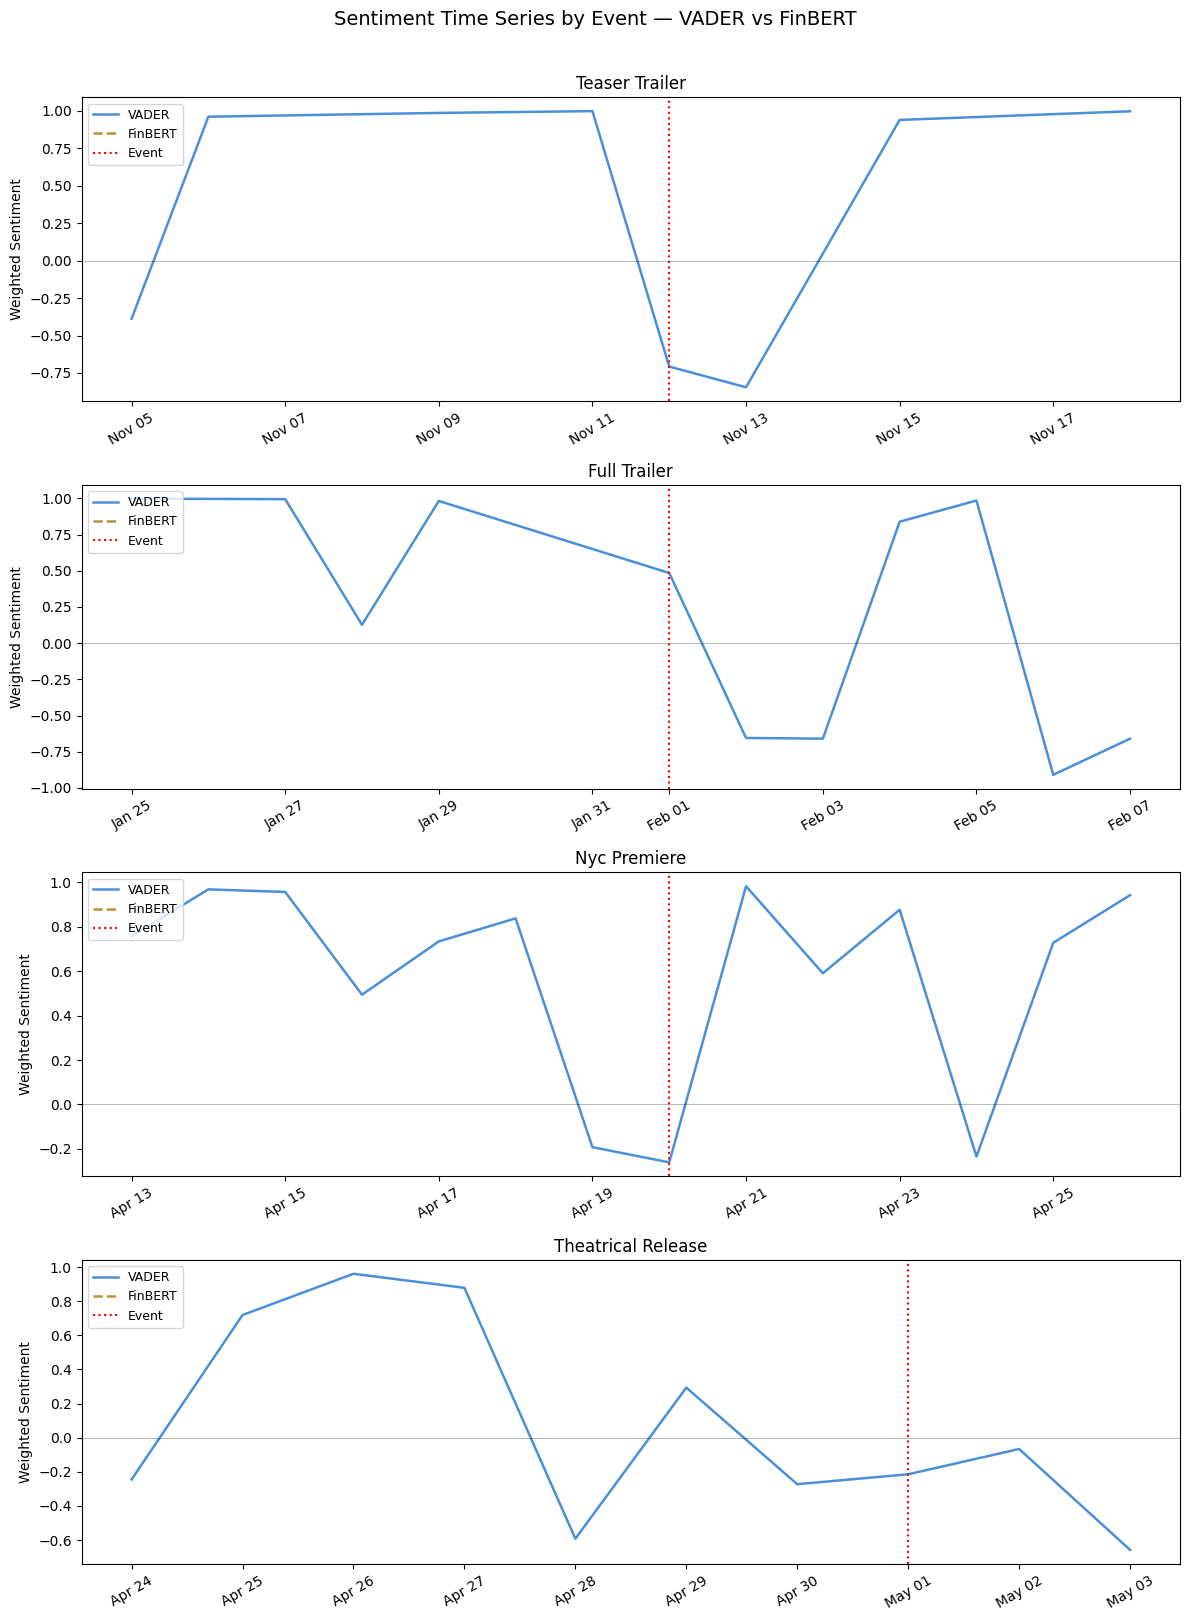

In [4]:
events = list(EVENT_DATES.keys())
fig, axes = plt.subplots(4, 1, figsize=(12, 16))

for ax, event in zip(axes, events):
    df = scores[scores['event'] == event].copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    event_dt = pd.Timestamp(EVENT_DATES[event])

    ax.plot(df['date'], df['vader_weighted'],   label='VADER',   color='#4A90D9', linewidth=1.8)
    ax.plot(df['date'], df['finbert_weighted'], label='FinBERT', color='#B5933A', linewidth=1.8, linestyle='--')
    ax.axvline(event_dt, color='red', linestyle=':', linewidth=1.5, label='Event')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(event.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Weighted Sentiment')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Sentiment Time Series by Event — VADER vs FinBERT', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/sentiment_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 2d. VADER vs FinBERT correlation

Skipped if FinBERT is unavailable (all NaN).

In [5]:
from scipy.stats import pearsonr, spearmanr

finbert_valid = scores['finbert_weighted'].dropna()
vader_valid   = scores['vader_weighted'].dropna()

if len(finbert_valid) < 2:
    print("FinBERT scores not available — skipping correlation (run with FinBERT enabled to compare models)")
else:
    # Align on same index
    both = scores[['vader_weighted','finbert_weighted']].dropna()
    r_p, p_p = pearsonr(both['vader_weighted'], both['finbert_weighted'])
    r_s, p_s = spearmanr(both['vader_weighted'], both['finbert_weighted'])
    print(f'Pearson r  = {r_p:.3f}  (p={p_p:.4f})')
    print(f'Spearman r = {r_s:.3f}  (p={p_s:.4f})')

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(both['vader_weighted'], both['finbert_weighted'], alpha=0.5, color='#B5933A', s=30)
    ax.set_xlabel('VADER Score')
    ax.set_ylabel('FinBERT Score')
    ax.set_title(f'VADER vs FinBERT\nPearson r={r_p:.3f}')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('../results/figures/vader_vs_finbert.png', dpi=150, bbox_inches='tight')
    plt.show()

FinBERT scores not available — skipping correlation (run with FinBERT enabled to compare models)


## 2e. Per-subreddit sentiment breakdown

Do finance subreddits skew differently from fashion subreddits?

In [6]:
from pathlib import Path

all_scored = []
for event in EVENT_DATES:
    p = Path(f'../data/processed/{event}_scored_posts.csv')
    if p.exists():
        df = pd.read_csv(p)
        df['event'] = event
        all_scored.append(df)

if all_scored:
    posts = pd.concat(all_scored, ignore_index=True)

    sub_sentiment = posts.groupby('subreddit')[['vader', 'finbert']].mean().round(3)
    sub_sentiment['n_posts'] = posts.groupby('subreddit').size()
    print(sub_sentiment.sort_values('vader', ascending=False))

                     vader  finbert  n_posts
subreddit                                   
investing            0.988      NaN        4
stocks               0.968      NaN        3
femalefashionadvice  0.867      NaN        9
malefashionadvice    0.598      NaN       44
fashion              0.369      NaN       16
westend              0.349      NaN       10
musicals             0.345      NaN       31
boxoffice            0.313      NaN      133
movies               0.246      NaN       51
